# 03 – ARIMA Forecasting Model

## Objective

This notebook develops an ARIMA model as a statistical baseline for forecasting the weekly EUR/USD closing exchange rate. A chronological train-test split will be used to avoid look-ahead bias.

In [1]:
import pandas as pd
import matplotlib.pyplot as plt

from statsmodels.tsa.stattools import adfuller
from statsmodels.tsa.arima.model import ARIMA
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from sklearn.metrics import mean_absolute_error
from sklearn.metrics import mean_squared_error
import numpy as np

In [2]:
df = pd.read_csv(
    "../data/processed/eur_weekly_clean.csv",
    parse_dates=["Date"]
)

df.head()

,Date,Price,Open,High,Low,Change %
0,2000-01-02,1.0292,1.0052,1.0417,1.0050,2.15
1,2000-01-09,1.0128,1.0288,1.0370,1.0111,-1.59
2,2000-01-16,1.0091,1.0128,1.0193,1.0049,-0.37
3,2000-01-23,0.9750,1.0026,1.0101,0.9738,-3.38
4,2000-01-30,0.9828,0.9779,0.9949,0.9662,0.80


In [3]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1371 entries, 0 to 1370
Data columns (total 6 columns):
 #   Column    Non-Null Count  Dtype         
---  ------    --------------  -----         
 0   Date      1371 non-null   datetime64[us]
 1   Price     1371 non-null   float64       
 2   Open      1371 non-null   float64       
 3   High      1371 non-null   float64       
 4   Low       1371 non-null   float64       
 5   Change %  1371 non-null   float64       
dtypes: datetime64[us](1), float64(5)
memory usage: 64.4 KB


## Chronological Train-Test Split

The EUR/USD closing-price series is divided chronologically into training and testing sets. The earliest 80% of observations are used for model training, while the most recent 20% are reserved for out-of-sample evaluation.

A random split is avoided because it would mix past and future observations and could introduce look-ahead bias.

In [4]:
series = df.set_index("Date")["Price"]

split_index = int(len(series) * 0.80)

train = series.iloc[:split_index]
test = series.iloc[split_index:]

print("Training observations:", len(train))
print("Testing observations:", len(test))
print("Training period:", train.index.min(), "to", train.index.max())
print("Testing period:", test.index.min(), "to", test.index.max())

Training observations: 1096
Testing observations: 275
Training period: 2000-01-02 00:00:00 to 2020-12-27 00:00:00
Testing period: 2021-01-03 00:00:00 to 2026-04-05 00:00:00


## Train-Test Split Visualization

The closing-price series is divided into training and testing subsets while preserving the chronological order of observations. The training data are used to estimate the ARIMA model, whereas the testing data are reserved for evaluating forecasting performance on unseen observations.

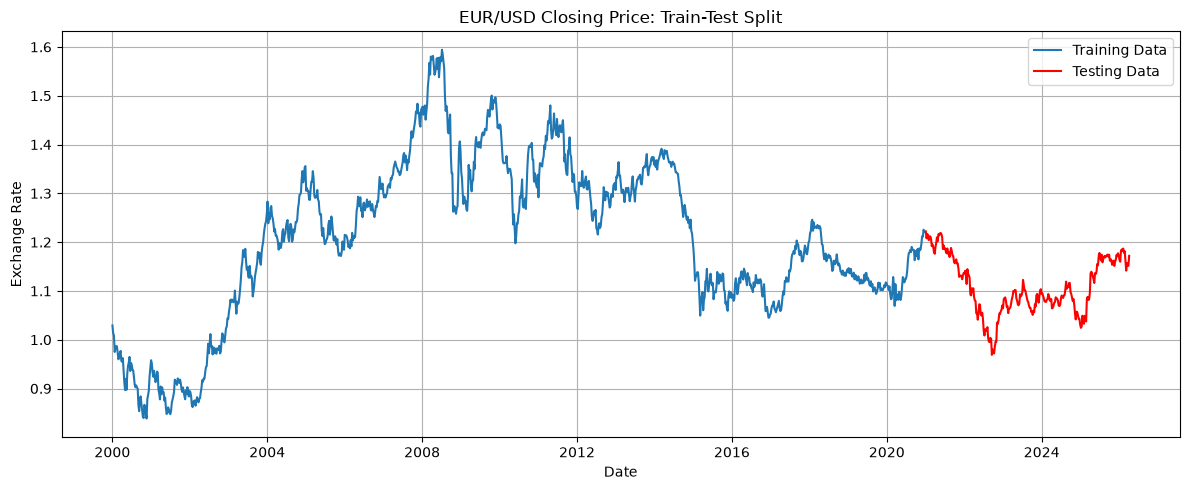

In [5]:
plt.figure(figsize=(12, 5))

plt.plot(train.index, train, label="Training Data")
plt.plot(test.index, test, label="Testing Data", color="red")

plt.title("EUR/USD Closing Price: Train-Test Split")
plt.xlabel("Date")
plt.ylabel("Exchange Rate")
plt.legend()
plt.grid(True)

plt.tight_layout()

plt.savefig("../outputs/figures/arima_train_test_split.png", dpi=300)

plt.show()

## Stationarity Test (Augmented Dickey-Fuller Test)

Before fitting an ARIMA model, it is necessary to determine whether the time series is stationary. The Augmented Dickey-Fuller (ADF) test is one of the most widely used statistical tests for this purpose.

The hypotheses of the test are:

- **Null hypothesis (H₀):** The time series is non-stationary.
- **Alternative hypothesis (H₁):** The time series is stationary.

If the p-value is less than 0.05, the null hypothesis is rejected, indicating that the series is stationary.

In [6]:
result = adfuller(train)

print("ADF Statistic :", result[0])
print("p-value       :", result[1])
print("")

print("Critical Values:")

for key, value in result[4].items():
    print(f"{key}: {value}")

ADF Statistic : -1.8285370484170802
p-value       : 0.3663886801452213

Critical Values:
1%: -3.436336023678866
5%: -2.8641831050780513
10%: -2.568177274243656


### Interpretation

The Augmented Dickey-Fuller (ADF) test produced a test statistic of **-1.8285** with a **p-value of 0.3664**. Since the p-value is greater than the 5% significance level (0.05), the null hypothesis of a unit root cannot be rejected.

Therefore, the weekly EUR/USD closing-price series is considered **non-stationary**. To satisfy the assumptions of the ARIMA model, first-order differencing is applied to remove the trend and stabilize the mean of the series.

## First-Order Differencing

To make the time series stationary, first-order differencing is performed by subtracting each observation from its previous observation.

The differenced series will then be tested again using the Augmented Dickey-Fuller test to verify whether stationarity has been achieved.

In [7]:
train_diff = train.diff().dropna()

train_diff.head()

Date
2000-01-09   -0.0164
2000-01-16   -0.0037
2000-01-23   -0.0341
2000-01-30    0.0078
2000-02-06    0.0041
Name: Price, dtype: float64

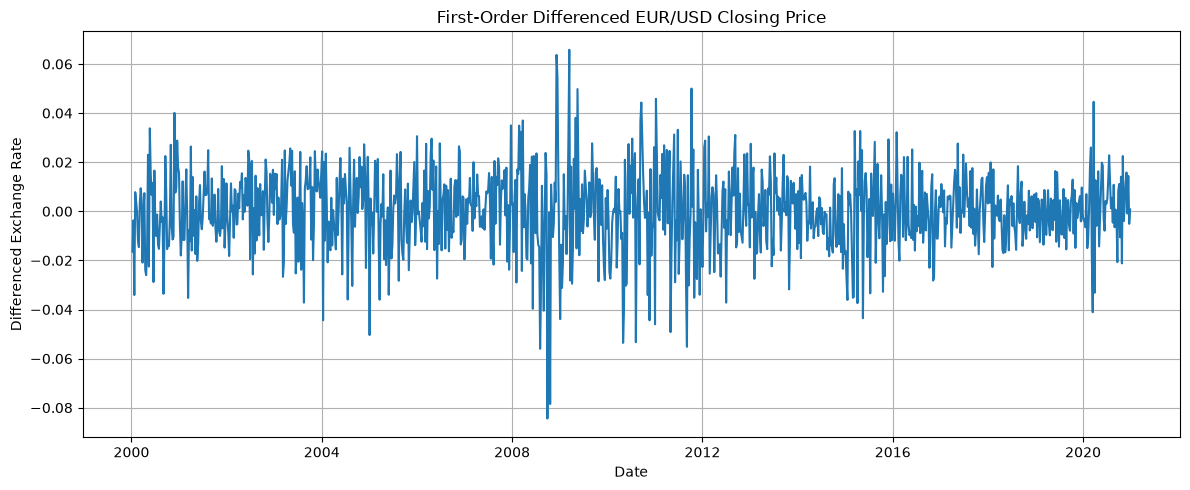

In [8]:
plt.figure(figsize=(12,5))

plt.plot(train_diff)

plt.title("First-Order Differenced EUR/USD Closing Price")
plt.xlabel("Date")
plt.ylabel("Differenced Exchange Rate")

plt.grid(True)

plt.tight_layout()

plt.savefig("../outputs/figures/arima_first_difference.png", dpi=300)

plt.show()

In [9]:
result_diff = adfuller(train_diff)

print("ADF Statistic :", result_diff[0])
print("p-value       :", result_diff[1])
print()

print("Critical Values:")

for key, value in result_diff[4].items():
    print(f"{key}: {value}")

ADF Statistic : -32.98633680841075
p-value       : 0.0

Critical Values:
1%: -3.436341508283391
5%: -2.864185524365606
10%: -2.5681785627437677


### Interpretation

After applying first-order differencing, the Augmented Dickey-Fuller (ADF) test was performed again. The test produced an ADF statistic of **-32.9863** with a **p-value of 0.0000**.

Since the p-value is well below the 5% significance level, the null hypothesis of a unit root is rejected. Therefore, the differenced EUR/USD closing-price series is stationary and satisfies the stationarity assumption required for ARIMA modelling.

Consequently, the differencing order for the ARIMA model is selected as **d = 1**.

## Autocorrelation Analysis

After achieving stationarity, the Autocorrelation Function (ACF) and Partial Autocorrelation Function (PACF) are examined to identify suitable autoregressive (p) and moving average (q) orders for the ARIMA model.

The ACF measures correlations between observations at different lags, while the PACF measures direct correlations after removing the effects of intermediate lags.

<Figure size 1000x500 with 0 Axes>

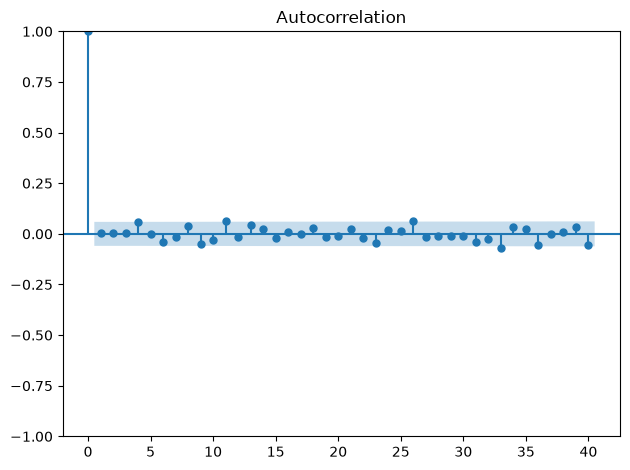

In [10]:
plt.figure(figsize=(10,5))

plot_acf(train_diff, lags=40)

plt.tight_layout()

plt.savefig("../outputs/figures/arima_acf.png", dpi=300)

plt.show()

<Figure size 1000x500 with 0 Axes>

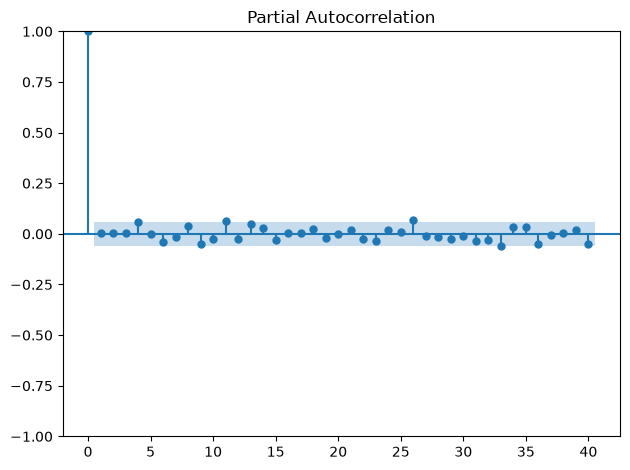

In [11]:
plt.figure(figsize=(10,5))

plot_pacf(train_diff, lags=40, method="ywm")

plt.tight_layout()

plt.savefig("../outputs/figures/arima_pacf.png", dpi=300)

plt.show()

## ARIMA Model Selection

Although the ACF and PACF plots provide initial guidance regarding the autoregressive (p) and moving average (q) orders, several candidate ARIMA models are estimated and compared using the Akaike Information Criterion (AIC).

The model with the lowest AIC is selected as the final forecasting model.

In [12]:
candidate_models = [
    (0,1,0),
    (1,1,0),
    (0,1,1),
    (1,1,1),
    (2,1,0),
    (0,1,2),
    (2,1,1),
    (1,1,2),
    (2,1,2)
]

results = []

for order in candidate_models:
    try:
        model = ARIMA(train, order=order)
        fitted = model.fit()

        results.append({
            "Order": order,
            "AIC": fitted.aic
        })

    except:
        pass

results_df = pd.DataFrame(results)

results_df.sort_values("AIC")

D:\project\sharemark\mainthesis\.venv312\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency W-SUN will be used.
  self._init_dates(dates, freq)
D:\project\sharemark\mainthesis\.venv312\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency W-SUN will be used.
  self._init_dates(dates, freq)
D:\project\sharemark\mainthesis\.venv312\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency W-SUN will be used.
  self._init_dates(dates, freq)
D:\project\sharemark\mainthesis\.venv312\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency W-SUN will be used.
  self._init_dates(dates, freq)
D:\project\sharemark\mainthesis\.venv312\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: Va

,Order,AIC
0,"(0, 1, 0)",-5907.198934
1,"(1, 1, 0)",-5905.205376
2,"(0, 1, 1)",-5905.204699
8,"(2, 1, 2)",-5904.212000
4,"(2, 1, 0)",-5903.220813
5,"(0, 1, 2)",-5903.219263
3,"(1, 1, 1)",-5903.198969
7,"(1, 1, 2)",-5901.221885
6,"(2, 1, 1)",-5901.198976


### Model Selection

Several candidate ARIMA models were estimated and compared using the Akaike Information Criterion (AIC). The model with the lowest AIC was selected because it provides the best balance between model fit and complexity.

Among all candidate models, **ARIMA(0,1,0)** achieved the lowest AIC value (-5907.20). Therefore, it was selected as the final baseline forecasting model for the EUR/USD weekly exchange rate.

## Final ARIMA Model

Based on the AIC comparison, the ARIMA(0,1,0) model is fitted using the training dataset. The fitted model is then used to generate forecasts for the testing period.

In [13]:
final_model = ARIMA(train, order=(0,1,0))

final_model_fit = final_model.fit()

print(final_model_fit.summary())

D:\project\sharemark\mainthesis\.venv312\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency W-SUN will be used.
  self._init_dates(dates, freq)
D:\project\sharemark\mainthesis\.venv312\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency W-SUN will be used.
  self._init_dates(dates, freq)
D:\project\sharemark\mainthesis\.venv312\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency W-SUN will be used.
  self._init_dates(dates, freq)


                               SARIMAX Results                                
Dep. Variable:                  Price   No. Observations:                 1096
Model:                 ARIMA(0, 1, 0)   Log Likelihood                2954.599
Date:                Wed, 09 Sep 2026   AIC                          -5907.199
Time:                        22:01:20   BIC                          -5902.200
Sample:                    01-02-2000   HQIC                         -5905.308
                         - 12-27-2020                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
sigma2         0.0003   8.32e-06     31.891      0.000       0.000       0.000
Ljung-Box (L1) (Q):                   0.01   Jarque-Bera (JB):               156.75
Prob(Q):                              0.94   Pr

In [14]:
forecast = final_model_fit.forecast(steps=len(test))

forecast.head()

2021-01-03    1.2212
2021-01-10    1.2212
2021-01-17    1.2212
2021-01-24    1.2212
2021-01-31    1.2212
Freq: W-SUN, Name: predicted_mean, dtype: float64

In [15]:
forecast_df = pd.DataFrame({
    "Actual": test,
    "Forecast": forecast
})

forecast_df.head()

,Actual,Forecast
2021-01-03,1.2218,1.2212
2021-01-10,1.2078,1.2212
2021-01-17,1.2167,1.2212
2021-01-24,1.2136,1.2212
2021-01-31,1.2042,1.2212


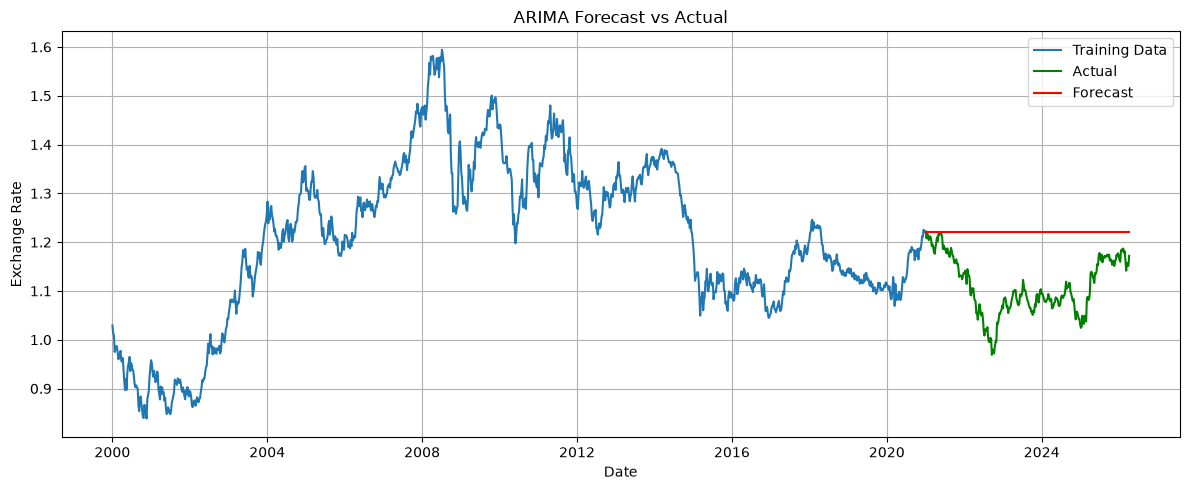

In [16]:
plt.figure(figsize=(12,5))

plt.plot(train.index, train, label="Training Data")
plt.plot(test.index, test, label="Actual", color="green")
plt.plot(forecast.index, forecast, label="Forecast", color="red")

plt.title("ARIMA Forecast vs Actual")
plt.xlabel("Date")
plt.ylabel("Exchange Rate")

plt.legend()
plt.grid(True)

plt.tight_layout()

plt.savefig("../outputs/figures/arima_forecast.png", dpi=300)

plt.show()

### Forecast Interpretation

The ARIMA(0,1,0) model generates a constant forecast equal to the final observation in the training dataset. This behavior is expected because the selected model represents a random walk process after first-order differencing.

Although the forecast does not capture short-term fluctuations in the EUR/USD exchange rate, it provides a statistically valid baseline model against which more advanced forecasting techniques can be compared.

In [17]:
mae = mean_absolute_error(test, forecast)

rmse = np.sqrt(mean_squared_error(test, forecast))

mape = np.mean(np.abs((test - forecast) / test)) * 100

print("MAE :", round(mae, 6))
print("RMSE:", round(rmse, 6))
print("MAPE:", round(mape, 2), "%")

MAE : 0.112185
RMSE: 0.126222
MAPE: 10.42 %


## Model Evaluation

The forecasting performance of the ARIMA model is evaluated using three commonly adopted error metrics:

- **Mean Absolute Error (MAE)** measures the average magnitude of forecasting errors.
- **Root Mean Squared Error (RMSE)** gives greater weight to larger forecasting errors.
- **Mean Absolute Percentage Error (MAPE)** expresses forecasting accuracy as a percentage, making it easier to interpret and compare.

In [18]:
mae = mean_absolute_error(test, forecast)
rmse = np.sqrt(mean_squared_error(test, forecast))
mape = np.mean(np.abs((test - forecast) / test)) * 100

print(f"MAE  : {mae:.6f}")
print(f"RMSE : {rmse:.6f}")
print(f"MAPE : {mape:.2f}%")

MAE  : 0.112185
RMSE : 0.126222
MAPE : 10.42%


## Evaluation Interpretation

The ARIMA(0,1,0) model achieved a Mean Absolute Error (MAE) of **0.1122**, a Root Mean Squared Error (RMSE) of **0.1262**, and a Mean Absolute Percentage Error (MAPE) of **10.42%** on the testing dataset.

The relatively low MAE and RMSE indicate that the model produces moderate forecasting errors. A MAPE of approximately **10%** suggests that the average prediction differs from the actual exchange rate by around ten percent.

Although the ARIMA model provides a statistically valid baseline for exchange rate forecasting, it fails to capture the short-term fluctuations observed in the testing period. This limitation is expected because the selected ARIMA(0,1,0) model represents a random walk process, producing nearly constant forecasts over the forecasting horizon.

The obtained results establish a benchmark against which the performance of the machine learning models developed in subsequent chapters can be objectively compared.